In [2]:
import pandas as pd
df = pd.read_csv('/Users/anugrapaul/dead-internet-detector/data/ai_human.csv')
df.head()

,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0


In [4]:
print(df.shape)
print(df.columns)


(487235, 2)
Index(['text', 'generated'], dtype='object')


In [5]:
print(df["generated"].value_counts())

generated
0.0    305797
1.0    181438
Name: count, dtype: int64


In [6]:
df.isnull().sum()

text         0
generated    0
dtype: int64

In [7]:
df['text_length']=df['text'].apply(len)

In [8]:
df['text_length'].describe()

count    487235.000000
mean       2269.586592
std         988.814028
min           1.000000
25%        1583.000000
50%        2102.000000
75%        2724.000000
max       18322.000000
Name: text_length, dtype: float64

In [9]:
human = df[df["generated"] == 0]
ai = df[df["generated"] == 1]

print("Human Avg Length:", human["text_length"].mean())
print("AI Avg Length:", ai["text_length"].mean())

Human Avg Length: 2354.592837732221
AI Avg Length: 2126.316411115643


In [10]:
df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))

In [11]:
df["word_count"].describe()

count    487235.000000
mean        393.096214
std         168.593328
min           0.000000
25%         278.000000
50%         363.000000
75%         471.000000
max        1668.000000
Name: word_count, dtype: float64

In [13]:
human = df[df["generated"] == 0]
ai = df[df["generated"] == 1]

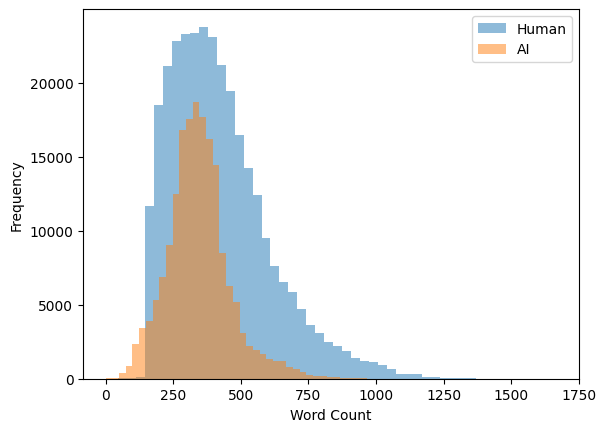

In [15]:
import matplotlib.pyplot as plt

plt.hist(
    human["word_count"],
    bins=50,
    alpha=0.5,
    label="Human"
)

plt.hist(
    ai["word_count"],
    bins=50,
    alpha=0.5,
    label="AI"
)

plt.legend()
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.savefig("word_count_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [18]:
sample = df["text"].iloc[0]

print(clean_text(sample))

cars cars have been around since they became famous in the 1900s when henry ford created and built the first modelt cars have played a major role in our every day lives since then but now people are starting to question if limiting car usage would be a good thing to me limiting the use of cars might be a good thing to do in like matter of this article in german suburb life goes on without cars by elizabeth rosenthal states how automobiles are the linchpin of suburbs where middle class families from either shanghai or chicago tend to make their homes experts say how this is a huge impediment to current efforts to reduce greenhouse gas emissions from tailpipe passenger cars are responsible for 12 percent of greenhouse gas emissions in europeand up to 50 percent in some carintensive areas in the united states cars are the main reason for the greenhouse gas emissions because of a lot of people driving them around all the time getting where they need to go article paris bans driving due to 

In [19]:
df["clean_text"] = df["text"].apply(clean_text)

In [20]:
df[["text", "clean_text"]].head()

,text,clean_text
0,Cars. Cars have been around since they became ...,cars cars have been around since they became f...
1,Transportation is a large necessity in most co...,transportation is a large necessity in most co...
2,"""America's love affair with it's vehicles seem...",americas love affair with its vehicles seems t...
3,How often do you ride in a car? Do you drive a...,how often do you ride in a car do you drive a ...
4,Cars are a wonderful thing. They are perhaps o...,cars are a wonderful thing they are perhaps on...


In [21]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["generated"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [24]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test_tfidf)

print(
    accuracy_score(y_test, preds)
)

0.9923342945395959


In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     61112
         1.0       0.99      0.99      0.99     36335

    accuracy                           0.99     97447
   macro avg       0.99      0.99      0.99     97447
weighted avg       0.99      0.99      0.99     97447



In [26]:
df["clean_text"].duplicated().sum()

np.int64(24217)

In [29]:
from collections import Counter

import string

In [30]:
def vocabulary_diversity(text):
    words = text.split()

    if len(words) == 0:
        return 0

    return len(set(words)) / len(words)

In [31]:
def avg_sentence_length(text):
    sentences = text.split('.')

    sentences = [
        s for s in sentences
        if s.strip()
    ]

    if len(sentences) == 0:
        return 0

    total_words = sum(
        len(s.split())
        for s in sentences
    )

    return total_words / len(sentences)

In [32]:
def repetition_score(text):
    words = text.split()

    if len(words) == 0:
        return 0

    counts = Counter(words)

    repeated = sum(
        c-1
        for c in counts.values()
        if c > 1
    )

    return repeated / len(words)

In [33]:
def punctuation_density(text):
    if len(text) == 0:
        return 0

    punct = sum(
        1
        for c in text
        if c in string.punctuation
    )

    return punct / len(text)

In [34]:
sample = df["text"].iloc[0]

print(vocabulary_diversity(sample))
print(avg_sentence_length(sample))
print(repetition_score(sample))
print(punctuation_density(sample))

0.5291095890410958
24.375
0.4708904109589041
0.022803283672848892


In [35]:
df_small = df.sample(
    50000,
    random_state=42
)

In [37]:
import pandas as pd

In [56]:
feature_df = pd.DataFrame({
    "diversity":
        df_small["clean_text"].apply(
            vocabulary_diversity
        ),

    "sentence_length":
        df_small["clean_text"].apply(
            avg_sentence_length
        ),

    "repetition":
        df_small["clean_text"].apply(
            repetition_score
        ),

    "punctuation":
        df_small["text"].apply(
            punctuation_density
        )
})

In [57]:
feature_df.head()

,diversity,sentence_length,repetition,punctuation
419952,0.451691,414.0,0.548309,0.028335
478535,0.221491,456.0,0.778509,0.012515
133753,0.511864,295.0,0.488136,0.028169
68011,0.537037,216.0,0.462963,0.018803
195939,0.536313,179.0,0.463687,0.026365


In [58]:
from sklearn.model_selection import train_test_split

X_text_train, X_text_test, X_feat_train, X_feat_test, y_train, y_test = train_test_split(
    df_small["clean_text"],
    feature_df,
    df_small["generated"],
    test_size=0.2,
    random_state=42
)

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_text_train)
X_test_tfidf = vectorizer.transform(X_text_test)

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_feat_train_scaled = scaler.fit_transform(X_feat_train)
X_feat_test_scaled = scaler.transform(X_feat_test)

In [61]:
from scipy.sparse import hstack

X_train_final = hstack([
    X_train_tfidf,
    X_feat_train_scaled
])

X_test_final = hstack([
    X_test_tfidf,
    X_feat_test_scaled
])

In [62]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_final,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [63]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test_final)

print(
    accuracy_score(y_test, preds)
)

0.9884


In [64]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      6327
         1.0       0.99      0.98      0.98      3673

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [65]:
import joblib

joblib.dump(model, "/Users/anugrapaul/dead-internet-detector/models/model.pkl")
joblib.dump(vectorizer, "/Users/anugrapaul/dead-internet-detector/models/vectorizer.pkl")
joblib.dump(scaler, "/Users/anugrapaul/dead-internet-detector/models/scaler.pkl")

['/Users/anugrapaul/dead-internet-detector/models/scaler.pkl']

In [66]:
df["clean_text"].duplicated().sum()

np.int64(24217)

In [67]:
df_small["clean_text"].duplicated().sum()

np.int64(262)

In [68]:
def predict_text(text):

    cleaned = clean_text(text)

    tfidf = vectorizer.transform([cleaned])

    features = pd.DataFrame({
        "diversity":[vocabulary_diversity(cleaned)],
        "sentence_length":[avg_sentence_length(cleaned)],
        "repetition":[repetition_score(cleaned)],
        "punctuation":[punctuation_density(text)]
    })

    scaled_features = scaler.transform(features)

    final_input = hstack([
        tfidf,
        scaled_features
    ])

    prediction = model.predict(final_input)[0]

    probabilities = model.predict_proba(final_input)[0]

    return {
        "prediction": int(prediction),
        "ai_probability": float(probabilities[1]),
        "human_probability": float(probabilities[0]),
        "diversity": float(features["diversity"][0]),
        "sentence_length": float(features["sentence_length"][0]),
        "repetition": float(features["repetition"][0]),
        "punctuation": float(features["punctuation"][0])
    }

In [69]:
print(scaler.feature_names_in_)

['diversity' 'sentence_length' 'repetition' 'punctuation']


In [70]:
text = 'don’t open global chat after joining the clan today bc it may cause your game to crash during your war hit'
print(predict_text(text))

{'prediction': 0, 'ai_probability': 0.2474654679813162, 'human_probability': 0.7525345320186838, 'diversity': 0.9523809523809523, 'sentence_length': 21.0, 'repetition': 0.047619047619047616, 'punctuation': 0.0}


In [71]:
text = 'Artificial intelligence has transformed modern software development by enabling developers to automate repetitive tasks, improve code quality, and accelerate deployment cycles. As machine learning models continue to evolve, organizations are increasingly adopting AI-driven solutions to remain competitive in a rapidly changing technological landscape.'
print(predict_text(text))

{'prediction': 1, 'ai_probability': 0.9879344065504557, 'human_probability': 0.012065593449544276, 'diversity': 0.9534883720930233, 'sentence_length': 43.0, 'repetition': 0.046511627906976744, 'punctuation': 0.017045454545454544}


In [73]:
text= '''Honestly I bought the game last week and it's been pretty fun so far. The combat takes some getting used to but once it clicks it's really satisfying.''' 
print(predict_text(text))

{'prediction': 1, 'ai_probability': 0.8670689560740403, 'human_probability': 0.13293104392595967, 'diversity': 0.9285714285714286, 'sentence_length': 28.0, 'repetition': 0.07142857142857142, 'punctuation': 0.02666666666666667}


In [74]:
text = '''The government announced a new infrastructure initiative on Thursday aimed at improving transportation networks across the country. Officials stated that the project is expected to generate thousands of jobs over the next five years.'''
print(predict_text(text))

{'prediction': 0, 'ai_probability': 0.4479756669065347, 'human_probability': 0.5520243330934653, 'diversity': 0.9117647058823529, 'sentence_length': 34.0, 'repetition': 0.08823529411764706, 'punctuation': 0.008583690987124463}


In [75]:
text = '''Today I'm gonna jump off a skybuilding. Shortly later I'll fly to jupiter and after that I will be eating curry. Then I will be playing fortnite on a toaster, and after that I will be swimming in lava.'''
print(predict_text(text))

{'prediction': 1, 'ai_probability': 0.853301464903598, 'human_probability': 0.14669853509640196, 'diversity': 0.7435897435897436, 'sentence_length': 39.0, 'repetition': 0.2564102564102564, 'punctuation': 0.029850746268656716}
